In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("your_dataset_5000.csv")
df.head()

,text,label
0,Exercise plays a crucial role in supporting me...,1
1,Renewable energy helps fight climate change by...,1
2,"A futuristic smart city is a vibrant, intercon...",1
3,Healthy eating habits are especially important...,1
4,Machine learning is transforming healthcare by...,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5000 non-null   str  
 1   label   5000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 395.5 KB


In [9]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [15]:
df.head()

,text,label
0,exercise plays a crucial role in supporting me...,1
1,renewable energy helps fight climate change by...,1
2,a futuristic smart city is a vibrant interconn...,1
3,healthy eating habits are especially important...,1
4,machine learning is transforming healthcare by...,1


In [37]:
pip install nltk

In [39]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Hardik
[nltk_data]     Agarwal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Hardik
[nltk_data]     Agarwal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Hardik
[nltk_data]     Agarwal\AppData\Roaming\nltk_data...


True

In [41]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [43]:
# Stopwords and Lemmatizer

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [45]:
# Text Preprocessing (Cleaning + Tokenization + Lemmatization)

def preprocess_text(text):

    text = text.lower()
    
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [49]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Hardik
[nltk_data]     Agarwal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Hardik
[nltk_data]     Agarwal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to C:\Users\Hardik
[nltk_data]     Agarwal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Hardik
[nltk_data]     Agarwal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [51]:
#Apply preprocessing

df["processed_text"] = df["text"].apply(preprocess_text)

df.head()

,text,label,processed_text
0,exercise plays a crucial role in supporting me...,1,exercise play crucial role supporting mental h...
1,renewable energy helps fight climate change by...,1,renewable energy help fight climate change red...
2,a futuristic smart city is a vibrant interconn...,1,futuristic smart city vibrant interconnected e...
3,healthy eating habits are especially important...,1,healthy eating habit especially important teen...
4,machine learning is transforming healthcare by...,1,machine learning transforming healthcare enabl...


In [53]:
#Features and Labels

X = df["processed_text"]
y = df["label"]

In [55]:
X

0       exercise play crucial role supporting mental h...
1       renewable energy help fight climate change red...
2       futuristic smart city vibrant interconnected e...
3       healthy eating habit especially important teen...
4       machine learning transforming healthcare enabl...
                              ...                        
4995           machine learning model detect cancer xrays
4996    blockchain provide secure transparent financia...
4997     volunteering animal shelter rewarding experience
4998           machine learning model detect cancer xrays
4999    cloud computing allows company scale faster ch...
Name: processed_text, Length: 5000, dtype: str

In [57]:
y

0       1
1       1
2       1
3       1
4       1
       ..
4995    1
4996    1
4997    0
4998    1
4999    1
Name: label, Length: 5000, dtype: int64

In [59]:
#Train Test Split


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
#TF-IDF Vectorization


from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

In [63]:
# Model Training


from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [65]:
y_pred = model.predict(X_test_vec)

In [67]:
y_pred

array([1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,

In [69]:
#accuracy check 

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.994


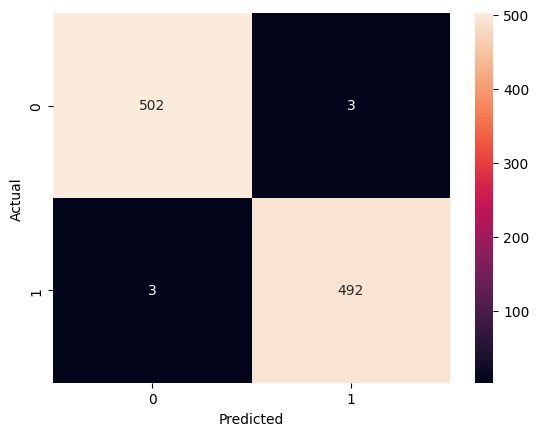

In [71]:
# Confusion Matrix


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [73]:
#Model Save


import joblib

joblib.dump(model, "ai_text_detector_model.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")

['tfidf_vectorizer.joblib']

In [75]:
#Custom Text Prediction


def predict_text(text):

    text = preprocess_text(text)

    vec = vectorizer.transform([text])

    prediction = model.predict(vec)

    if prediction[0] == 1:
        print("AI Generated Text")
    else:
        print("Human Written Text")

In [77]:
predict_text("Artificial intelligence is transforming the world")

AI Generated Text


In [81]:
# Convert test data into TF-IDF vectors
X_test_vec = vectorizer.transform(X_test)

# Prediction
y_pred = model.predict(X_test_vec)

# Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.994


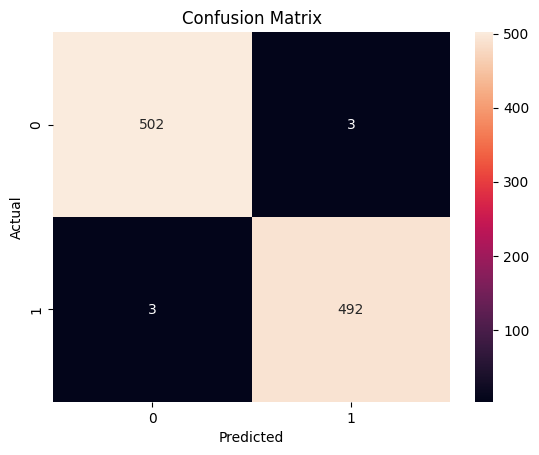

In [83]:
# Confusion Matrix


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [85]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       505
           1       0.99      0.99      0.99       495

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [89]:
# Word Cloud Visualization

!pip install wordcloud

   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   --- ------------------------------------ 30.7/307.2 kB 1.3 MB/s eta 0:00:01
   ----- --------------------------------- 41.0/307.2 kB 653.6 kB/s eta 0:00:01
   ----------- --------------------------- 92.2/307.2 kB 751.6 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/307.2 kB 798.9 kB/s eta 0:00:01
   --------------------------- ---------- 225.3/307.2 kB 981.9 kB/s eta 0:00:01
   ------------------------------------- -- 286.7/307.2 kB 1.0 MB/s eta 0:00:01
   ---------------------------------------  307.2/307.2 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  307.2/307.2 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  307.2/307.2 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  307.2/307.2 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  307.2/307.2 kB 

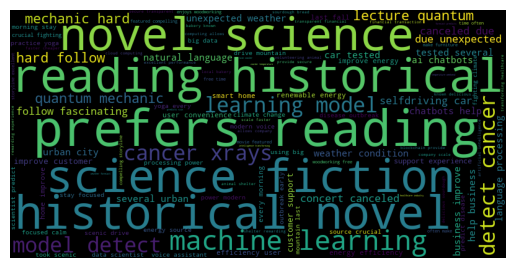

In [91]:
from wordcloud import WordCloud

text = " ".join(df["processed_text"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [93]:
# Model Save

import pickle

pickle.dump(model, open("ai_text_detector_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

In [95]:
# Final Testing

predict_text("The quick brown fox jumps over the lazy dog")
predict_text("AI generated content is becoming more common today")

Human Written Text
AI Generated Text


In [97]:
import pickle

loaded_model = pickle.load(open("ai_text_detector_model.pkl", "rb"))
loaded_vectorizer = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

text = "Artificial intelligence is changing the future of education"

text = preprocess_text(text)

vec = loaded_vectorizer.transform([text])

prediction = loaded_model.predict(vec)

print(prediction)

[1]


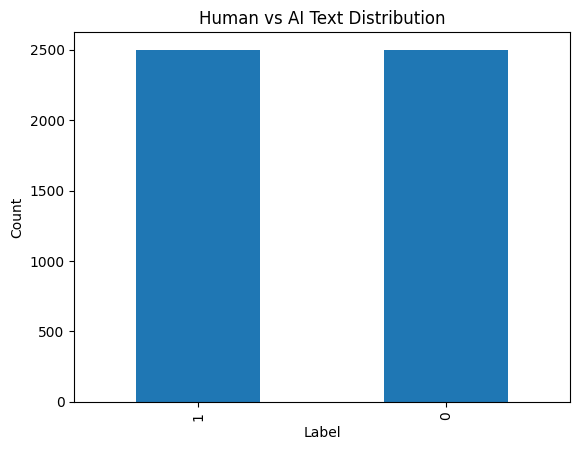

In [99]:
# graph visualization 

import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Human vs AI Text Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()